# 04. 모델 선택 — 같은 피처·같은 검증으로 공정하게 비교

## 이 노트북의 목적 (Phase 3)

Phase 2에서 만든 **179개 피처는 고정**해 두고, "어떤 예측 모델을 쓸 것인가"만 바꿔 가며 비교한다.
비교 조건을 하나라도 다르게 하면(피처가 다르거나 검증 기간이 다르면) **어느 쪽이 좋은지 알 수 없게 되므로**,
아래를 모든 후보에 똑같이 적용한다.

| 고정 조건 | 값 |
|---|---|
| 피처 | Phase 2의 179개 전부 |
| 학습 기간 | 2022-01-01 ~ 2023-12-31 |
| 검증 기간 | **2024년 전체 (홀드아웃)** — 한 번도 학습에 쓰지 않는다 |
| 평가 산식 | `src/metric.py`의 대회 공식 산식 그대로 |
| 랜덤 시드 | 42 (전 모델 동일) |
| 후처리 | `clip(0, 설비용량)` |

## 이 노트북이 답해야 할 질문 3개

1. **모델이 물리 예측치(`pc_pred`)를 실제로 이기는가?** 못 이기면 머신러닝을 쓸 이유가 없다.
2. **어떤 모델 계열이 이 데이터에 맞는가?** 근거 없이 "요즘 LightGBM 많이 쓰니까"로 고르지 않는다.
   데이터의 형태를 먼저 재고, 그 형태에 맞는 모델을 문헌 근거와 함께 고른다.
3. **손실함수를 무엇으로 둘 것인가?** 대회 산식은 MAE 기반인데, 기본값(제곱오차)으로 학습하면 산식과 어긋난다.

## 지킬 규칙 (누수 방지 — CLAUDE.md 4번)

- **2024년은 오직 마지막 평가에만 쓴다.** 하이퍼파라미터를 고르거나 학습을 조기 종료(early stopping)할 때
  2024년을 보면, 2024년 점수가 실제보다 좋게 나와 우리 자신을 속인다.
  → 조기 종료용으로 **학습 기간 안에 다시 시간 분할**을 만든다 (2022-01~2023-06 학습 / 2023-07~12 내부검증).
- **스케일러(표준화)는 train에서만 fit** 하고 검증·test에는 transform만 적용한다.
- Phase 2의 파워커브·풍속 보정식도 이미 2022~2023년만으로 fit되어 있다 (`reports/phase2_features.md` §2-7).

## 0. 준비 — 라이브러리, 상수, 시드 고정

재현성(CLAUDE.md 12번)을 위해 파이썬·numpy·각 모델의 시드를 모두 고정한다.
GBDT는 멀티스레드로 학습하면 부동소수점 덧셈 순서가 달라져 결과가 미세하게 흔들릴 수 있으므로,
결정론적(deterministic) 옵션을 켜고 스레드 수도 고정한다.

In [1]:
import os, random, time, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 대회 산식은 절대 노트북에 복사하지 않고 import해서 쓴다 (CLAUDE.md 8번)
import sys
sys.path.insert(0, ".")
from src.metric import metric, metric_by_group, TARGET_COLS, CAPACITY_KWH

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------- 시드 고정 (재현성: CLAUDE.md 12번) ----------
RNG_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RNG_SEED)
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
N_THREADS = 4          # 스레드 수를 고정해야 부동소수점 덧셈 순서가 매번 같아진다

# ---------- 경로 ----------
PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
EXP_DIR = Path("experiments"); EXP_DIR.mkdir(exist_ok=True)

# ---------- 시간 분할 (CLAUDE.md 4번: 시간 기반 분할, 랜덤 K-Fold 금지) ----------
VAL_START = pd.Timestamp("2024-01-01 01:00:00")        # 2024년 = 홀드아웃 검증
INNER_VAL_START = pd.Timestamp("2023-07-01 01:00:00")  # 조기 종료용 내부 검증 시작

# 채점 대상 기준: 이용률 10% 이상 (src/metric.py와 동일)
SCORE_THRESHOLD = 0.10

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
print("준비 완료 | lightgbm", lgb.__version__, "| xgboost", xgb.__version__)

준비 완료 | lightgbm 4.6.0 | xgboost 3.3.0


## 1. 데이터 형태 확인 — 모델을 고르기 전에 반드시 먼저 할 일

"어떤 모델이 좋은가"는 데이터의 형태에 따라 달라진다. 논문을 읽기 전에 **우리 데이터가 어떤 모양인지**부터 잰다.
아래 6가지를 확인한다.

1. **규모**: 행 수와 피처 수. 딥러닝이 통할 만큼 데이터가 많은가?
2. **그룹별 학습 가능 행 수**: 그룹 3은 라벨이 2023년부터만 있다. 얼마나 적은가?
3. **타깃 분포**: 정규분포인가? 상한이 있는가?
4. **그룹 1과 2가 얼마나 같은가**: 하나의 모델로 둘 다 예측해도 되는가?
5. **피처끼리 얼마나 겹치는가(다중공선성)**: 선형 모델에 치명적, 트리에는 무해.
6. **분포 이동**: test(2025)가 train과 다른가? 다르면 외삽 능력이 중요해진다.

In [2]:
feat_train = pd.read_parquet(PROCESSED_DIR / "features_train.parquet")
feat_test = pd.read_parquet(PROCESSED_DIR / "features_test.parquet")

FEATURE_COLS = [c for c in feat_test.columns if c != "forecast_kst_dtm"]
dtm = feat_train["forecast_kst_dtm"]

train_mask = dtm < VAL_START           # 2022~2023
val_mask = dtm >= VAL_START            # 2024 (홀드아웃)

print("=" * 78)
print("1) 규모")
print("=" * 78)
print(f"train 전체 {feat_train.shape} | test {feat_test.shape} | 피처 {len(FEATURE_COLS)}개")
print(f"학습 2022~2023: {train_mask.sum():,}행 | 검증 2024: {val_mask.sum():,}행")

print("\n" + "=" * 78)
print("2) 그룹별 학습 가능 행 수 (라벨이 있는 행만 학습할 수 있다)")
print("=" * 78)
rows = []
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    has_label = feat_train[g].notna()
    n_fit = int((has_label & train_mask).sum())
    n_val = int((has_label & val_mask).sum())
    n_scored = int((has_label & val_mask & (feat_train[g] >= cap * SCORE_THRESHOLD)).sum())
    rows.append({"그룹": g, "학습(22~23)": n_fit, "검증(2024)": n_val,
                 "검증 채점대상": n_scored, "채점 비율": f"{n_scored/n_val*100:.1f}%",
                 "행/피처": round(n_fit / len(FEATURE_COLS), 1)})
print(pd.DataFrame(rows).to_string(index=False))

1) 규모
train 전체 (26304, 183) | test (8760, 180) | 피처 179개
학습 2022~2023: 17,520행 | 검증 2024: 8,784행

2) 그룹별 학습 가능 행 수 (라벨이 있는 행만 학습할 수 있다)
         그룹  학습(22~23)  검증(2024)  검증 채점대상 채점 비율  행/피처
kpx_group_1      17422      8778     4990 56.8%  97.3
kpx_group_2      17423      8778     4977 56.7%  97.3
kpx_group_3       8760      8778     4567 52.0%  48.9


In [3]:
print("=" * 78)
print("3) 타깃 분포 — 정규분포인가? (이용률 = 발전량 / 설비용량)")
print("=" * 78)
for g in TARGET_COLS:
    cf = (feat_train[g] / CAPACITY_KWH[g]).dropna()
    print(f"{g}: 평균 {cf.mean():.3f} | 중앙값 {cf.median():.3f} | 왜도 {cf.skew():+.3f} | "
          f"거의 0(<2%) {(cf < 0.02).mean()*100:4.1f}% | 거의 정격(>95%) {(cf > 0.95).mean()*100:.1f}%")
print("\n→ 평균 > 중앙값이고 왜도가 양수 = 오른쪽으로 긴 꼬리. 정규분포가 아니다.")
print("→ 0 근처에 23~30%가 몰려 있고, 위로는 설비용량이라는 물리적 상한이 있다 (유계 분포).")

print("\n" + "=" * 78)
print("4) 그룹 1과 2는 하나의 모델로 묶어도 되는가")
print("=" * 78)
print("라벨 상관행렬:")
print(feat_train[TARGET_COLS].corr().to_string(float_format=lambda x: f"{x:.4f}"))
diff = (feat_train["kpx_group_1"] - feat_train["kpx_group_2"]).abs() / CAPACITY_KWH["kpx_group_1"]
print(f"\n|group_1 - group_2| / 설비용량: 중앙값 {diff.median():.4f}, 평균 {diff.mean():.4f}, 90분위 {diff.quantile(0.9):.4f}")
print(f"→ FICR 만점 밴드는 오차율 6%(={0.06:.2f}) 이내다. 두 그룹의 실제 차이가 중앙값 {diff.median()*100:.1f}%,")
print(f"   90분위 {diff.quantile(0.9)*100:.1f}%나 된다. 같은 값을 예측하면 그 자체로 밴드를 잡아먹는다.")
print("   → 상관이 0.955로 높아도 그룹별로 모델을 따로 학습해야 한다.")

3) 타깃 분포 — 정규분포인가? (이용률 = 발전량 / 설비용량)
kpx_group_1: 평균 0.307 | 중앙값 0.197 | 왜도 +0.668 | 거의 0(<2%) 23.1% | 거의 정격(>95%) 1.9%
kpx_group_2: 평균 0.328 | 중앙값 0.203 | 왜도 +0.581 | 거의 0(<2%) 23.3% | 거의 정격(>95%) 1.5%
kpx_group_3: 평균 0.265 | 중앙값 0.129 | 왜도 +0.940 | 거의 0(<2%) 30.2% | 거의 정격(>95%) 2.3%

→ 평균 > 중앙값이고 왜도가 양수 = 오른쪽으로 긴 꼬리. 정규분포가 아니다.
→ 0 근처에 23~30%가 몰려 있고, 위로는 설비용량이라는 물리적 상한이 있다 (유계 분포).

4) 그룹 1과 2는 하나의 모델로 묶어도 되는가
라벨 상관행렬:
             kpx_group_1  kpx_group_2  kpx_group_3
kpx_group_1       1.0000       0.9553       0.9037
kpx_group_2       0.9553       1.0000       0.9283
kpx_group_3       0.9037       0.9283       1.0000

|group_1 - group_2| / 설비용량: 중앙값 0.0308, 평균 0.0617, 90분위 0.1703
→ FICR 만점 밴드는 오차율 6%(=0.06) 이내다. 두 그룹의 실제 차이가 중앙값 3.1%,
   90분위 17.0%나 된다. 같은 값을 예측하면 그 자체로 밴드를 잡아먹는다.
   → 상관이 0.955로 높아도 그룹별로 모델을 따로 학습해야 한다.


In [4]:
print("=" * 78)
print("5) 피처끼리 얼마나 겹치는가 (다중공선성)")
print("=" * 78)
_sub = feat_train.loc[train_mask, FEATURE_COLS].sample(n=8000, random_state=RNG_SEED)
_cm = _sub.corr().abs().to_numpy().copy()
np.fill_diagonal(_cm, 0.0)
_pairs = _cm[np.triu_indices_from(_cm, k=1)]
print(f"피처쌍 |상관| 평균 {_pairs.mean():.3f}")
print(f"  |상관| > 0.90 인 쌍: {int((_pairs > 0.90).sum()):,} / {len(_pairs):,} ({(_pairs > 0.90).mean()*100:.1f}%)")
print(f"  |상관| > 0.99 인 쌍: {int((_pairs > 0.99).sum()):,}")
print("\n→ 거의 똑같은 피처 쌍이 많다(같은 풍속의 격자별 값, lag/lead 등).")
print("   선형회귀는 다중공선성에서 계수가 폭주하므로 정규화(Ridge)가 필수다.")
print("   결정트리는 둘 중 하나를 골라 자르면 그만이라 영향이 거의 없다.")

print("\n" + "=" * 78)
print("6) 분포 이동 — test(2025)가 train과 다른가")
print("=" * 78)
_keys = ["ldaps_ws117_mean", "gfs_ws117_mean", "t_hub_c", "rho_hub", "icing_score"]
_rows = []
for c in _keys:
    _rows.append({
        "피처": c,
        "학습 22~23": feat_train.loc[train_mask, c].mean(),
        "검증 2024": feat_train.loc[val_mask, c].mean(),
        "test 2025": feat_test[c].mean(),
        "2025 - train": feat_test[c].mean() - feat_train.loc[train_mask, c].mean(),
    })
print(pd.DataFrame(_rows).to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
print("\n→ test(2025)의 예보 풍속이 학습 기간보다 눈에 띄게 높다(+0.6 m/s 이상).")
print("   '트리 모델은 학습 범위 밖을 예측하지 못한다'는 약점이 문제가 되는지 다음 셀에서 직접 확인한다.")

5) 피처끼리 얼마나 겹치는가 (다중공선성)


피처쌍 |상관| 평균 0.370
  |상관| > 0.90 인 쌍: 1,188 / 15,931 (7.5%)
  |상관| > 0.99 인 쌍: 96

→ 거의 똑같은 피처 쌍이 많다(같은 풍속의 격자별 값, lag/lead 등).
   선형회귀는 다중공선성에서 계수가 폭주하므로 정규화(Ridge)가 필수다.
   결정트리는 둘 중 하나를 골라 자르면 그만이라 영향이 거의 없다.

6) 분포 이동 — test(2025)가 train과 다른가
              피처  학습 22~23  검증 2024  test 2025  2025 - train
ldaps_ws117_mean    8.9803   8.8368     9.5663        0.5860
  gfs_ws117_mean    3.9650   3.9046     4.2412        0.2762
         t_hub_c    6.7198   7.4140     6.9250        0.2052
         rho_hub    1.1043   1.1016     1.1028       -0.0015
     icing_score    0.0479   0.0903     0.0672        0.0193

→ test(2025)의 예보 풍속이 학습 기간보다 눈에 띄게 높다(+0.6 m/s 이상).
   '트리 모델은 학습 범위 밖을 예측하지 못한다'는 약점이 문제가 되는지 다음 셀에서 직접 확인한다.


### 1-1. "트리는 외삽을 못 한다" — 우리 데이터에서 실제로 문제가 되는가

결정트리 계열의 잘 알려진 약점이 있다. 트리는 학습 데이터를 구간으로 잘라 각 구간의 평균/중앙값을 답으로 내므로,
**학습에서 본 적 없는 범위의 입력이 들어오면 가장 가까운 구간의 값을 그대로 되풀이**한다.
즉 학습 타깃의 최댓값보다 큰 값은 절대 예측하지 못한다.

방금 6번에서 test(2025) 풍속이 train보다 +0.63 m/s 높다는 것을 봤으니, 이 약점을 걱정해야 할 것 같다.
**하지만 "평균이 이동한 것"과 "범위를 벗어난 것"은 전혀 다른 문제다.** 직접 재 본다.

In [5]:
print("핵심 피처의 train 범위 vs test 값")
print("-" * 92)
for c in ["ldaps_ws117_mean", "ldaps_g13_ws117", "gfs_ws117_mean",
          "ws_hub_cal_kpx_group_1", "pc_pred_kpx_group_1", "t_hub_c"]:
    a, b = feat_train.loc[train_mask, c], feat_test[c]
    over = ((b > a.max()) | (b < a.min())).mean()
    print(f"{c:>24}: train [{a.min():8.3f}, {a.max():9.3f}] | test [{b.min():8.3f}, {b.max():9.3f}] "
          f"| 범위 이탈 {over*100:.3f}%")

# 179개 피처 전부에 대해 "test가 train 범위를 벗어나는 행" 비율
_out = [(c, float(((feat_test[c] > feat_train.loc[train_mask, c].max()) |
                   (feat_test[c] < feat_train.loc[train_mask, c].min())).mean()))
        for c in FEATURE_COLS]
_out.sort(key=lambda x: -x[1])
print("\n범위 이탈이 큰 피처 상위 5개:")
for c, f in _out[:5]:
    print(f"  {c:>28}: {f*100:.3f}%")
print(f"\n전체 179개 피처 평균 범위 이탈률: {np.mean([f for _, f in _out])*100:.4f}%")

핵심 피처의 train 범위 vs test 값
--------------------------------------------------------------------------------------------
        ldaps_ws117_mean: train [   0.333,    34.032] | test [   0.432,    28.095] | 범위 이탈 0.000%
         ldaps_g13_ws117: train [   0.023,    36.069] | test [   0.196,    30.503] | 범위 이탈 0.000%
          gfs_ws117_mean: train [   0.313,    21.716] | test [   0.646,    20.285] | 범위 이탈 0.000%
  ws_hub_cal_kpx_group_1: train [   2.137,    19.022] | test [   2.051,    16.296] | 범위 이탈 0.011%
     pc_pred_kpx_group_1: train [   0.000, 19999.277] | test [   0.000, 19999.277] | 범위 이탈 0.000%
                 t_hub_c: train [ -24.035,    28.381] | test [ -20.490,    27.681] | 범위 이탈 0.000%

범위 이탈이 큰 피처 상위 5개:
                        t850_c: 0.388%
                         gh500: 0.160%
                 lapse_850_500: 0.148%
               src_ws117_ratio: 0.091%
                     gfs_vrate: 0.080%

전체 179개 피처 평균 범위 이탈률: 0.0084%


**결론: 트리의 외삽 약점은 이 문제에서 발동하지 않는다.** 세 가지 이유가 있다.

1. **범위 이탈이 사실상 0이다.** 풍속 계열 핵심 피처는 test가 train 범위를 벗어나는 행이 **정확히 0%**다.
   +0.63 m/s는 "학습에서 본 적 없는 강풍이 분다"가 아니라 **"이미 본 범위 안에서 평균이 조금 옮겨갔다"** 는 뜻이다.
2. **타깃에 물리적 상한이 있다.** 발전량은 설비용량(21,600 / 21,000 kWh)을 넘을 수 없다.
   학습 데이터에 이미 정격 출력 시간이 충분히 들어 있으므로, 트리가 예측해야 할 값의 범위 밖은 애초에 존재하지 않는다.
3. **파워커브는 고풍속에서 평평하다.** 강풍이 더 세져도 출력은 정격에서 더 오르지 않는다.
   즉 트리가 "마지막 구간 값을 되풀이"하는 동작이 **오히려 물리적으로 옳다.** 여기서는 약점이 아니라 올바른 귀납 편향이다.

(만약 타깃이 주가처럼 상한 없이 자라는 값이었다면 이 판단은 정반대가 되었을 것이다.
"트리는 외삽을 못 한다"는 명제는 참이지만, **그것이 문제가 되는지는 데이터마다 다르다.** 그래서 직접 쟀다.)

## 2. 모델 후보 선정 — 문헌 근거

1절에서 잰 데이터의 형태를 요약하면 이렇다.

| 특성 | 값 | 함의 |
|---|---|---|
| 형태 | 표 형태(tabular), 수치형만 | 이미지·문장이 아니다 |
| 규모 | 학습 17,520행 × 179피처 (그룹 3은 8,760행) | **중소 규모** |
| 타깃 | 유계·왜도 있는 연속값 | 정규분포 가정 모델은 부적합 |
| 다중공선성 | \|상관\|>0.9인 쌍이 7.6% | 선형은 정규화 필수, 트리는 무해 |
| 외삽 필요성 | 없음 (범위 이탈 ≈ 0%, 타깃 상한 존재) | 트리의 약점이 발동 안 함 |

### 2-1. 왜 GBDT(그래디언트 부스팅 트리)인가

- **표 형태 중소규모 데이터에서 GBDT가 딥러닝을 앞선다는 것이 벤치마크의 반복된 결론**이다.
  GBDT는 **표본 3,000 ~ 1,000,000개 구간**에서 최고 성능을 낸다고 보고된다 [1][2].
  우리 데이터(17,520행)는 정확히 그 구간의 아래쪽에 있다.
- 원인으로 지목되는 것은 **귀납 편향(inductive bias)** 이다. 트리는 축에 나란한 경계로 자르므로
  "풍속 3m/s 아래는 발전 0" 같은 **불연속·계단형 관계**를 곧바로 표현한다.
  신경망은 회전 불변(rotationally invariant)이라 이런 구조를 처음부터 다시 배워야 한다 [2].
  파워커브(cut-in, 정격 포화)가 바로 그 계단형 관계다.
- **풍력 예측 대회의 우승 해법이 실제로 GBDT다.** GEFCom 2012는 시간·기상 파생 피처 + GBDT로 우승했고 [3],
  2024년 HREFTC 우승팀은 NWP 소스별 CatBoost + 격자점의 raw/lagged/differenced 피처를 썼다 [4].

### 2-2. 딥러닝을 배제하지 않고 "검증"하는 방법

CLAUDE.md 11번은 "딥러닝은 데이터가 적어 과적합 위험을 **명시적으로 검증**하라"고 요구한다.
그런데 신경망 하나를 제대로 학습·튜닝하려면 그 자체로 Phase 하나가 필요하다.
그래서 이번 Phase에서는 **선형 모델(Ridge)을 "GBDT가 아닌 쪽"의 대표로 세운다.**

- Ridge는 신경망과 같은 **매끄러운(smooth) 함수 계열**이고, 계단형 관계를 표현하지 못한다는 약점을 공유한다.
- 학습이 결정론적이고 순식간에 끝나며 하이퍼파라미터가 하나(`alpha`)뿐이라 **공정 비교가 쉽다.**
- Ridge가 GBDT에 크게 뒤진다면 "이 데이터는 계단형·비선형 구조가 지배적"이라는 증거가 되고,
  그 구조를 배우려면 신경망은 훨씬 많은 데이터가 필요하다는 논거가 된다.
- 반대로 Ridge가 대등하다면 관계가 거의 선형이라는 뜻이므로, 그때 신경망을 진지하게 검토한다.

### 2-3. 비교할 후보 6가지

| # | 이름 | 무엇을 확인하려는가 |
|---|---|---|
| 0a | `pc_pred` (물리 예측치 그대로) | **모델 없이도 얼마나 맞히는가.** 이걸 못 넘으면 ML을 쓸 이유가 없다 |
| 0b | `pc_pred_rho` (밀도 보정판) | 밀도 보정이 실제로 도움이 되는가 |
| 1 | **Ridge** (선형 + 정규화) | 비(非)트리 계열 대표. 관계가 선형인가? |
| 2 | **LightGBM (L1 손실)** | GBDT 표준. 대회 산식(MAE 기반)에 맞춘 손실 |
| 3 | **LightGBM (L2 손실)** | **손실함수만 바꾼 대조군.** L1이 정말 유리한지 확인 |
| 4 | **XGBoost (L1 손실)** | 다른 GBDT 구현. LightGBM이 우연히 잘 나온 게 아닌지 |
| 5 | **CatBoost (MAE 손실)** | HREFTC 2024 우승 해법이 쓴 구현 [4] |
| 6 | **LightGBM 잔차 학습** | 타깃을 `실제 - pc_pred`로 두는 물리+통계 하이브리드 [CLAUDE.md 13번] |

## 3. 손실함수를 무엇으로 둘 것인가 — 산식에서 역산하기

이 부분은 **점수에 직접 영향을 주는데 놓치기 쉬운 곳**이라 따로 설명한다.

대회 산식은 `total_score = 0.5·(1 - NMAE) + 0.5·FICR` 이다.

- **NMAE**는 `|예측 - 실제|`의 평균이다. 즉 **절대오차(L1)** 다.
- **FICR**는 오차율이 6% 이내면 만점, 6~8%면 3/4점, 그 밖은 0점인 **계단 함수**다.

그런데 대부분의 회귀 모델은 기본값이 **제곱오차(L2, MSE)** 다. 둘의 차이는 결정적이다.

| 손실 | 최적 예측값 | 큰 오차에 대한 태도 |
|---|---|---|
| L2 (제곱오차) | 조건부 **평균** | 하나의 큰 오차를 줄이려고 전체를 희생 |
| **L1 (절대오차)** | 조건부 **중앙값** | 큰 오차 하나를 포기하고 다수를 정확히 맞힘 |

**왜 L1이 맞는가**: 어느 시각의 발전량이 "보통 10,000kWh인데 가끔 2,000kWh(터빈 정지)"라고 하자.
L2는 평균인 8,000 근처를 예측해 **평소에도 2,000kWh씩 틀린다**(오차율 9.3% → FICR 0점).
L1은 중앙값인 10,000을 예측해 **대부분의 시간을 6% 밴드 안에 넣고**, 가끔 오는 정지 시간만 크게 틀린다.

FICR이 계단 함수라는 점이 이 선택을 더 강하게 만든다. **8%를 넘긴 오차는 9%든 50%든 똑같이 0점**이므로,
큰 오차를 줄이려 애쓸 이유가 전혀 없다. 대신 **경계에 걸친 시간을 밴드 안으로 밀어 넣는 것**이 점수다.
이것이 정확히 L1(중앙값 회귀)이 하는 일이다.

→ 그래서 후보 2번(L1)과 3번(L2)을 **다른 조건은 전부 똑같이 두고** 비교해 이 논리를 숫자로 확인한다.

## 4. 검증 설계 — 2024년을 어떻게 지킬 것인가

GBDT는 트리를 몇 개 쌓을지(`n_estimators`)를 정해야 한다. 너무 적으면 덜 배우고, 너무 많으면 과적합한다.
보통 **조기 종료(early stopping)** 로 정한다: 검증 점수가 더 이상 좋아지지 않으면 멈춘다.

**여기에 함정이 있다.** 조기 종료에 2024년을 쓰면, 2024년 데이터를 "몇 그루에서 멈출지"를 고르는 데 쓴 것이다.
그러면 2024년 점수는 더 이상 정직한 홀드아웃 점수가 아니다 (CLAUDE.md 4번).

**해결**: 학습 기간 안에서 다시 시간 분할을 만든다.

```
|<---------- 학습 기간 2022-01 ~ 2023-12 ---------->|<--- 홀드아웃 2024 --->|
|<-- 내부학습 2022-01~2023-06 -->|<- 내부검증 23-07~12 ->|      (건드리지 않음)
        (조기 종료 기준을 여기서 정함)
```

1. 내부학습으로 학습하고 **내부검증**에서 조기 종료 → 최적 트리 개수 `best_iter`를 얻는다.
2. 그 개수를 **학습 데이터가 늘어난 비율만큼 키워서**(`× 전체행수/내부학습행수`) 2022~2023 **전체**로 다시 학습한다.
   데이터가 많아지면 같은 성능에 더 많은 트리가 필요하기 때문이다.
3. 완성된 모델로 **2024년을 딱 한 번** 예측해 점수를 낸다.

조기 종료의 기준도 산식에 맞춘다. **내부검증 중 채점 대상(이용률 ≥ 10%)인 시간만** 골라 그 MAE로 판단한다.
NMAE는 MAE를 설비용량(상수)으로 나눈 값이므로, 채점 대상 시간의 MAE를 최소화하는 것이 곧 NMAE 최소화다.

In [6]:
# 그룹별로 (학습 X/y, 내부학습, 내부검증, 홀드아웃) 인덱스를 만든다.
# 라벨이 없는 행(kpx_group_3의 2022년 등)은 학습에서 제외한다 -- 0으로 채우지 않는다 (CLAUDE.md 8번).

def build_splits(group: str):
    """
    한 그룹에 대해 학습/내부검증/홀드아웃 마스크를 만든다.

    입력: group -- "kpx_group_1" 등
    출력: dict. 각 값은 feat_train에 대한 boolean 마스크(pd.Series).
        fit_all : 2022~2023 중 라벨이 있는 행 (최종 학습용)
        inner_tr: 2022-01 ~ 2023-06 중 라벨이 있는 행 (조기 종료 탐색용 학습)
        inner_va: 2023-07 ~ 2023-12 중 라벨이 있는 행 (조기 종료 기준)
        holdout : 2024년 전체 (라벨 유무 무관 -- 산식이 NaN을 알아서 제외한다)
    누수 (CLAUDE.md 4번): holdout은 어떤 학습·선택에도 쓰이지 않는다.
    """
    has_label = feat_train[group].notna()
    return {
        "fit_all":  has_label & (dtm < VAL_START),
        "inner_tr": has_label & (dtm < INNER_VAL_START),
        "inner_va": has_label & (dtm >= INNER_VAL_START) & (dtm < VAL_START),
        "holdout":  dtm >= VAL_START,
    }


def scored_mask(group: str, mask: pd.Series) -> pd.Series:
    """
    주어진 마스크 중 '대회 채점 대상'(실제 이용률 >= 10%)인 행만 남긴다.
    조기 종료 기준을 산식과 일치시키기 위해 사용한다.
    """
    return mask & (feat_train[group] >= CAPACITY_KWH[group] * SCORE_THRESHOLD)


for g in TARGET_COLS:
    s = build_splits(g)
    print(f"{g}: 최종학습 {int(s['fit_all'].sum()):,} | 내부학습 {int(s['inner_tr'].sum()):,} | "
          f"내부검증 {int(s['inner_va'].sum()):,} (그중 채점대상 {int(scored_mask(g, s['inner_va']).sum()):,}) | "
          f"홀드아웃 {int(s['holdout'].sum()):,}")

kpx_group_1: 최종학습 17,422 | 내부학습 13,009 | 내부검증 4,413 (그중 채점대상 2,652) | 홀드아웃 8,784
kpx_group_2: 최종학습 17,423 | 내부학습 13,009 | 내부검증 4,414 (그중 채점대상 2,663) | 홀드아웃 8,784
kpx_group_3: 최종학습 8,760 | 내부학습 4,344 | 내부검증 4,416 (그중 채점대상 2,311) | 홀드아웃 8,784


## 5. 평가 함수 — 대회 산식 그대로

`src/metric.py`의 `metric()`을 import해서 쓴다. 노트북에 산식을 복사하지 않는다 (CLAUDE.md 8번).

예측값은 저장 전에 반드시 **`clip(0, 설비용량)`** 한다. 음수 발전량이나 설비용량 초과는 물리적으로 불가능하고,
대회 제출 규칙에서도 금지된다 (CLAUDE.md 7번).

`metric()`은 실제값이 NaN인 행을 자동으로 제외한다 (`NaN >= 임계값`이 항상 False이므로).
따라서 2024년 8,784행을 통째로 넣어도 라벨이 없는 6행은 알아서 빠진다.

In [7]:
def clip_prediction(pred: np.ndarray, group: str) -> np.ndarray:
    """예측값을 물리적으로 가능한 범위 [0, 설비용량]으로 자른다 (CLAUDE.md 5번 후처리 기본기)."""
    return np.clip(pred, 0.0, CAPACITY_KWH[group])


def evaluate_holdout(preds: dict) -> dict:
    """
    2024년 홀드아웃에서 대회 산식으로 점수를 낸다.

    입력: preds -- {"kpx_group_1": 예측배열(홀드아웃 길이), ...}
    출력: dict. total_score / one_minus_nmae / ficr / 그룹별 nmae·ficr
    """
    hold = dtm >= VAL_START
    answer = feat_train.loc[hold, TARGET_COLS].reset_index(drop=True)
    pred_df = pd.DataFrame({g: clip_prediction(preds[g], g) for g in TARGET_COLS})
    assert len(answer) == len(pred_df)
    assert not pred_df.isna().any().any(), "예측값에 결측이 있습니다"

    total, one_minus_nmae, ficr = metric(answer, pred_df)
    by_group = metric_by_group(answer, pred_df)
    out = {"total_score": total, "one_minus_nmae": one_minus_nmae, "ficr": ficr}
    for g in TARGET_COLS:
        out[f"nmae_{g[-1]}"] = by_group[g]["nmae"]
        out[f"ficr_{g[-1]}"] = by_group[g]["ficr"]
    return out


def error_rate(preds: dict, group: str) -> np.ndarray:
    """채점 대상 시간의 오차율(=|예측-실제|/설비용량) 배열. FICR 밴드 분석용."""
    hold = dtm >= VAL_START
    actual = feat_train.loc[hold, group].to_numpy(dtype=float)
    cap = CAPACITY_KWH[group]
    valid = actual >= cap * SCORE_THRESHOLD
    return np.abs(clip_prediction(preds[group], group)[valid] - actual[valid]) / cap


print("평가 함수 준비 완료. 채점 대상 시간 수(2024):",
      {g: int((feat_train.loc[dtm >= VAL_START, g] >= CAPACITY_KWH[g] * SCORE_THRESHOLD).sum()) for g in TARGET_COLS})

평가 함수 준비 완료. 채점 대상 시간 수(2024): {'kpx_group_1': 4990, 'kpx_group_2': 4977, 'kpx_group_3': 4567}


## 6. 베이스라인 0 — 모델 없이 물리 예측치만으로

Phase 2에서 만든 `pc_pred_{group}`(예보 풍속 → 보정 → 파워커브)을 **그대로 제출한다면** 몇 점인가?

**이 점수를 못 넘는 모델은 존재 이유가 없다.** 모든 이후 실험은 이 숫자와 비교된다.

In [8]:
hold = dtm >= VAL_START
baseline_results = {}

for name, col_tpl in [("baseline_pc_pred", "pc_pred_{g}"), ("baseline_pc_pred_rho", "pc_pred_rho_{g}")]:
    preds = {g: feat_train.loc[hold, col_tpl.format(g=g)].to_numpy() for g in TARGET_COLS}
    baseline_results[name] = evaluate_holdout(preds)

base_df = pd.DataFrame(baseline_results).T
print("[2024 홀드아웃 — 모델 없이 물리 예측치만]")
print(base_df.to_string(float_format=lambda x: f"{x:.4f}"))
BASELINE_SCORE = base_df.loc["baseline_pc_pred", "total_score"]
print(f"\n→ 기준선 total_score = {BASELINE_SCORE:.4f}")

[2024 홀드아웃 — 모델 없이 물리 예측치만]
                      total_score  one_minus_nmae   ficr  nmae_1  ficr_1  nmae_2  ficr_2  nmae_3  ficr_3
baseline_pc_pred           0.5717          0.8437 0.2998  0.1518  0.2928  0.1552  0.3558  0.1621  0.2508
baseline_pc_pred_rho       0.5601          0.8389 0.2813  0.1581  0.2716  0.1584  0.3366  0.1667  0.2356

→ 기준선 total_score = 0.5717


## 7. 모델 정의

모든 모델이 **같은 함수 골격**을 따른다: 내부검증으로 조기 종료 → 트리 개수 확정 → 전체 학습 → 홀드아웃 예측.
이렇게 해야 "어떤 모델은 조기 종료를 했고 어떤 모델은 안 했다" 같은 불공정이 생기지 않는다.

하이퍼파라미터는 **세 GBDT에 최대한 대응되는 값**으로 맞췄다 (학습률 0.05, 깊이/잎 수 유사, L2 정규화 1.0).
정밀 튜닝은 Phase 4의 일이다. 여기서는 **모델 계열 간 비교**가 목적이므로 어느 한쪽만 튜닝하면 안 된다.

In [9]:
LR = 0.05              # 학습률: 세 GBDT 공통
MAX_ROUNDS = 3000      # 조기 종료가 알아서 멈춘다
EARLY_STOP = 100       # 이만큼 개선이 없으면 중단


def _xy(group, mask):
    """마스크에 해당하는 (피처행렬 X, 타깃 y)를 뽑는다."""
    return feat_train.loc[mask, FEATURE_COLS].to_numpy(dtype=np.float32), \
           feat_train.loc[mask, group].to_numpy(dtype=np.float64)


def _scale_iters(best_iter, sp):
    """
    내부학습(작은 데이터)에서 찾은 최적 트리 수를, 전체 학습(큰 데이터)용으로 키운다.
    데이터가 늘면 같은 성능에 더 많은 트리가 필요하기 때문이다.
    """
    ratio = sp["fit_all"].sum() / max(sp["inner_tr"].sum(), 1)
    return max(int(round(best_iter * ratio)), 50)


def fit_lightgbm(group, sp, objective="l1", residual=False):
    """
    LightGBM 학습. objective="l1"이면 절대오차(중앙값 회귀), "l2"면 제곱오차(평균 회귀).
    residual=True이면 타깃을 (실제 - 물리예측치)로 두고, 예측 시 물리예측치를 다시 더한다.
    """
    params = dict(objective=objective, learning_rate=LR, num_leaves=63, min_data_in_leaf=40,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                  verbosity=-1, seed=RNG_SEED, num_threads=N_THREADS,
                  deterministic=True, force_row_wise=True)   # 매번 같은 결과가 나오도록

    pc_col = f"pc_pred_{group}"
    def target(mask):
        y = feat_train.loc[mask, group].to_numpy(dtype=np.float64)
        return y - feat_train.loc[mask, pc_col].to_numpy() if residual else y

    # 1단계: 내부검증(채점 대상 시간만)으로 최적 트리 수 찾기
    Xi, Xv = feat_train.loc[sp["inner_tr"], FEATURE_COLS], feat_train.loc[scored_mask(group, sp["inner_va"]), FEATURE_COLS]
    dtr = lgb.Dataset(Xi, label=target(sp["inner_tr"]))
    dva = lgb.Dataset(Xv, label=target(scored_mask(group, sp["inner_va"])), reference=dtr)
    booster = lgb.train(params, dtr, num_boost_round=MAX_ROUNDS, valid_sets=[dva],
                        callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    best = booster.best_iteration

    # 2단계: 확정된 트리 수로 2022~2023 전체 재학습
    n_final = _scale_iters(best, sp)
    dfull = lgb.Dataset(feat_train.loc[sp["fit_all"], FEATURE_COLS], label=target(sp["fit_all"]))
    final = lgb.train(params, dfull, num_boost_round=n_final)

    # 3단계: 홀드아웃 예측
    pred = final.predict(feat_train.loc[sp["holdout"], FEATURE_COLS])
    if residual:
        pred = pred + feat_train.loc[sp["holdout"], pc_col].to_numpy()
    return pred, final, {"best_iter_inner": best, "n_final": n_final}


def fit_xgboost(group, sp):
    """XGBoost, 절대오차(reg:absoluteerror) 손실."""
    params = dict(objective="reg:absoluteerror", learning_rate=LR, max_depth=6,
                  min_child_weight=20, subsample=0.8, colsample_bytree=0.7, reg_lambda=1.0,
                  tree_method="hist", seed=RNG_SEED, nthread=N_THREADS)
    Xi, yi = _xy(group, sp["inner_tr"])
    sv = scored_mask(group, sp["inner_va"]); Xv, yv = _xy(group, sv)
    dtr, dva = xgb.DMatrix(Xi, yi), xgb.DMatrix(Xv, yv)
    bst = xgb.train(params, dtr, num_boost_round=MAX_ROUNDS, evals=[(dva, "val")],
                    early_stopping_rounds=EARLY_STOP, verbose_eval=False)
    best = bst.best_iteration + 1

    n_final = _scale_iters(best, sp)
    Xf, yf = _xy(group, sp["fit_all"])
    final = xgb.train(params, xgb.DMatrix(Xf, yf), num_boost_round=n_final)
    Xh, _ = _xy(group, sp["holdout"])
    return final.predict(xgb.DMatrix(Xh)), final, {"best_iter_inner": best, "n_final": n_final}


def fit_catboost(group, sp):
    """CatBoost, MAE 손실. HREFTC 2024 우승 해법이 쓴 구현 [4]."""
    common = dict(loss_function="MAE", learning_rate=LR, depth=6, l2_leaf_reg=3.0,
                  random_seed=RNG_SEED, thread_count=N_THREADS, verbose=False, allow_writing_files=False)
    Xi, yi = _xy(group, sp["inner_tr"])
    sv = scored_mask(group, sp["inner_va"]); Xv, yv = _xy(group, sv)
    m = CatBoostRegressor(iterations=MAX_ROUNDS, early_stopping_rounds=EARLY_STOP, **common)
    m.fit(Xi, yi, eval_set=(Xv, yv))
    best = m.get_best_iteration() + 1

    n_final = _scale_iters(best, sp)
    Xf, yf = _xy(group, sp["fit_all"])
    final = CatBoostRegressor(iterations=n_final, **common).fit(Xf, yf)
    Xh, _ = _xy(group, sp["holdout"])
    return final.predict(Xh), final, {"best_iter_inner": best, "n_final": n_final}


def fit_ridge(group, sp):
    """
    Ridge(정규화 선형회귀). 비(非)트리 계열 대표.
    표준화(StandardScaler)는 반드시 학습 데이터에서만 fit한다 (CLAUDE.md 4번: test는 transform만).
    규제 강도 alpha는 내부검증의 채점대상 MAE로 고른다 (2024는 보지 않는다).
    """
    Xi, yi = _xy(group, sp["inner_tr"])
    sv = scored_mask(group, sp["inner_va"]); Xv, yv = _xy(group, sv)

    sc_inner = StandardScaler().fit(Xi)                 # 내부학습에서만 fit
    best_alpha, best_mae = None, np.inf
    for a in [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]:
        m = Ridge(alpha=a, random_state=RNG_SEED).fit(sc_inner.transform(Xi), yi)
        mae = np.abs(m.predict(sc_inner.transform(Xv)) - yv).mean()
        if mae < best_mae:
            best_alpha, best_mae = a, mae

    Xf, yf = _xy(group, sp["fit_all"])
    sc_full = StandardScaler().fit(Xf)                  # 최종 학습 데이터에서만 fit
    final = Ridge(alpha=best_alpha, random_state=RNG_SEED).fit(sc_full.transform(Xf), yf)
    Xh, _ = _xy(group, sp["holdout"])
    return final.predict(sc_full.transform(Xh)), final, {"alpha": best_alpha}


print("모델 정의 완료")

모델 정의 완료


## 8. 실행 — 6개 후보를 같은 조건으로 학습·평가

각 후보마다 그룹 3개씩, 총 18번 학습한다. 학습 시간도 함께 기록한다
(발표 자료의 "모델 비교 표"에 학습시간 열이 필요하다 — CLAUDE.md 11번 Phase 3).

In [10]:
MODEL_SPECS = [
    ("ridge",            lambda g, sp: fit_ridge(g, sp)),
    ("lightgbm_l1",      lambda g, sp: fit_lightgbm(g, sp, objective="l1")),
    ("lightgbm_l2",      lambda g, sp: fit_lightgbm(g, sp, objective="l2")),
    ("xgboost_l1",       lambda g, sp: fit_xgboost(g, sp)),
    ("catboost_mae",     lambda g, sp: fit_catboost(g, sp)),
    ("lightgbm_residual", lambda g, sp: fit_lightgbm(g, sp, objective="l1", residual=True)),
]

results, all_preds, fitted_models, fit_info = {}, {}, {}, {}

for name, fn in MODEL_SPECS:
    t0 = time.time()
    preds, models, infos = {}, {}, {}
    for g in TARGET_COLS:
        sp = build_splits(g)
        p, m, info = fn(g, sp)
        preds[g], models[g], infos[g] = p, m, info
    elapsed = time.time() - t0

    res = evaluate_holdout(preds)
    res["fit_seconds"] = elapsed
    results[name] = res
    all_preds[name] = preds
    fitted_models[name] = models
    fit_info[name] = infos
    print(f"{name:>20}: total_score {res['total_score']:.4f} | 1-NMAE {res['one_minus_nmae']:.4f} | "
          f"FICR {res['ficr']:.4f} | {elapsed:5.1f}초")

D:\공모전\wind-forecast_Competition\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8904673260731215e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
D:\공모전\wind-forecast_Competition\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8904673260731215e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


D:\공모전\wind-forecast_Competition\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0431342900574236e-07.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


               ridge: total_score 0.5926 | 1-NMAE 0.8688 | FICR 0.3164 |   0.3초


         lightgbm_l1: total_score 0.6074 | 1-NMAE 0.8690 | FICR 0.3459 |  21.9초


         lightgbm_l2: total_score 0.5969 | 1-NMAE 0.8679 | FICR 0.3259 |   6.7초


          xgboost_l1: total_score 0.6049 | 1-NMAE 0.8689 | FICR 0.3409 |  15.0초


        catboost_mae: total_score 0.6016 | 1-NMAE 0.8680 | FICR 0.3353 |  85.0초


   lightgbm_residual: total_score 0.5996 | 1-NMAE 0.8666 | FICR 0.3325 |  32.7초


## 9. 결과 — 모델 비교표

`total_score`가 최종 순위 지표이므로 이것으로 정렬한다.
다만 **개선 방향 판단에는 NMAE를 먼저 본다** — NMAE는 연속 지표라 작은 개선도 안정적으로 잡히는 반면
FICR은 계단식이라 노이즈가 크다 (CLAUDE.md 5번).

그룹별 분해 지표를 반드시 함께 본다. 그룹 3이 평균을 깎고 있는지 즉시 확인해야 한다.

In [11]:
comp = pd.DataFrame({**baseline_results, **results}).T
comp["fit_seconds"] = comp["fit_seconds"].fillna(0.0)
comp = comp.sort_values("total_score", ascending=False)

cols = ["total_score", "one_minus_nmae", "ficr", "nmae_1", "nmae_2", "nmae_3", "ficr_1", "ficr_2", "ficr_3", "fit_seconds"]
print("[2024 홀드아웃 — 전체 비교표 (total_score 내림차순)]")
print(comp[cols].to_string(float_format=lambda x: f"{x:.4f}"))

best_name = comp.index[0]
print(f"\n최고 모델: {best_name} (total_score {comp.loc[best_name, 'total_score']:.4f})")
print(f"물리 베이스라인 대비 개선: {comp.loc[best_name, 'total_score'] - BASELINE_SCORE:+.4f}")

print("\n[손실함수 비교 — 다른 조건은 완전히 동일]")
if "lightgbm_l1" in comp.index and "lightgbm_l2" in comp.index:
    for k in ["total_score", "one_minus_nmae", "ficr"]:
        d = comp.loc["lightgbm_l1", k] - comp.loc["lightgbm_l2", k]
        print(f"  {k:>16}: L1 {comp.loc['lightgbm_l1', k]:.4f} vs L2 {comp.loc['lightgbm_l2', k]:.4f}  (L1 - L2 = {d:+.4f})")

[2024 홀드아웃 — 전체 비교표 (total_score 내림차순)]
                      total_score  one_minus_nmae   ficr  nmae_1  nmae_2  nmae_3  ficr_1  ficr_2  ficr_3  fit_seconds
lightgbm_l1                0.6074          0.8690 0.3459  0.1236  0.1226  0.1469  0.3450  0.4271  0.2656      21.8715
xgboost_l1                 0.6049          0.8689 0.3409  0.1243  0.1239  0.1451  0.3404  0.4132  0.2691      14.9612
catboost_mae               0.6016          0.8680 0.3353  0.1251  0.1251  0.1457  0.3320  0.4066  0.2671      84.9810
lightgbm_residual          0.5996          0.8666 0.3325  0.1247  0.1249  0.1505  0.3385  0.4114  0.2476      32.6690
lightgbm_l2                0.5969          0.8679 0.3259  0.1229  0.1220  0.1514  0.3432  0.3785  0.2560       6.6905
ridge                      0.5926          0.8688 0.3164  0.1256  0.1252  0.1429  0.3093  0.3740  0.2660       0.3487
baseline_pc_pred           0.5717          0.8437 0.2998  0.1518  0.1552  0.1621  0.2928  0.3558  0.2508       0.0000
baseline_pc_pred

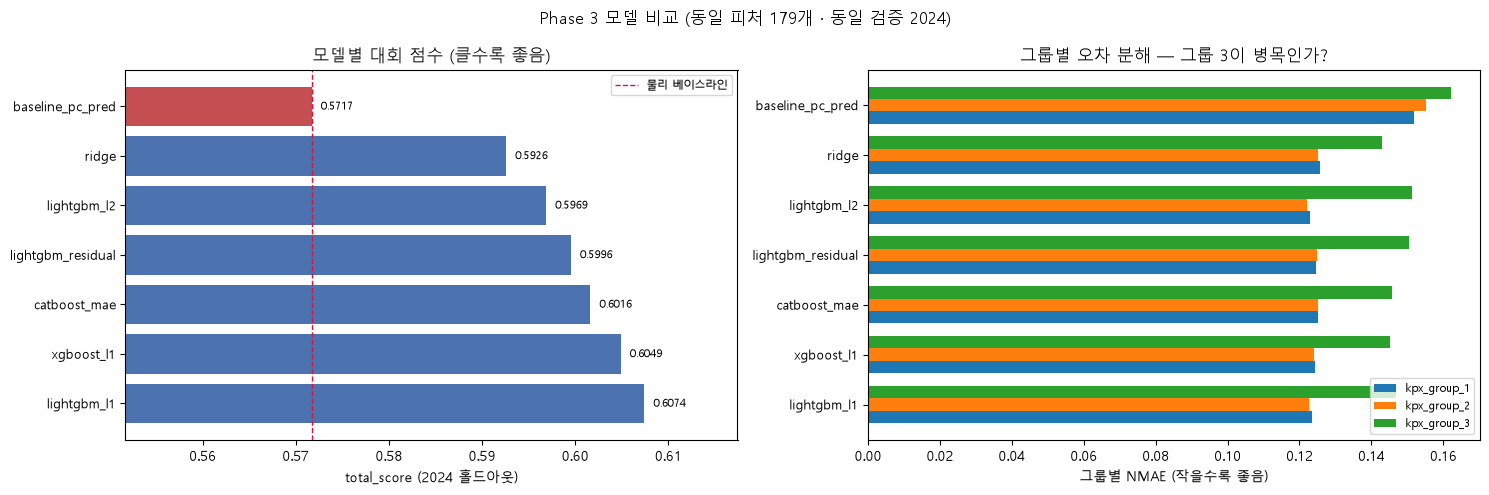

In [12]:
# 모델별 total_score / 그룹별 NMAE 시각화
plot_df = comp.loc[[i for i in comp.index if i != "baseline_pc_pred_rho"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

y = np.arange(len(plot_df))
colors = ["#C44E52" if i.startswith("baseline") else "#4C72B0" for i in plot_df.index]
axes[0].barh(y, plot_df["total_score"], color=colors)
axes[0].set_yticks(y); axes[0].set_yticklabels(plot_df.index, fontsize=9)
axes[0].axvline(BASELINE_SCORE, color="crimson", ls="--", lw=1, label="물리 베이스라인")
axes[0].set_xlabel("total_score (2024 홀드아웃)")
axes[0].set_xlim(min(plot_df["total_score"]) - 0.02, max(plot_df["total_score"]) + 0.01)
axes[0].legend(fontsize=8); axes[0].set_title("모델별 대회 점수 (클수록 좋음)")
for i, v in enumerate(plot_df["total_score"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

w = 0.25
for i, gi in enumerate([1, 2, 3]):
    axes[1].barh(y + (i - 1) * w, plot_df[f"nmae_{gi}"], height=w, label=f"kpx_group_{gi}")
axes[1].set_yticks(y); axes[1].set_yticklabels(plot_df.index, fontsize=9)
axes[1].set_xlabel("그룹별 NMAE (작을수록 좋음)")
axes[1].legend(fontsize=8); axes[1].set_title("그룹별 오차 분해 — 그룹 3이 병목인가?")

fig.suptitle("Phase 3 모델 비교 (동일 피처 179개 · 동일 검증 2024)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase3_model_comparison.png", dpi=120)
plt.show()

## 10. FICR 밴드 분석 — 점수가 실제로 어디서 새는가

FICR은 계단 함수다. 오차율이 **6% 이내면 만점(4점), 6~8%면 3점, 8% 초과면 0점**이다.
그래서 "평균 오차"보다 **"6% 밴드 안에 들어간 시간의 비율"** 이 점수를 지배한다.

오차율 히스토그램을 그려 두 경계(6%, 8%)를 표시하면, 개선의 여지가 어디에 있는지 바로 보인다.

- 8% 바로 오른쪽에 봉우리가 있다 → **조금만 밀어 넣으면 0점이 3점으로** 바뀐다. 큰 기회.
- 6% 바로 오른쪽에 봉우리가 있다 → 3점을 4점으로 올릴 기회.
- 대부분이 8% 훨씬 오른쪽에 있다 → 밴드 조정으로는 안 되고 모델 자체를 개선해야 한다.

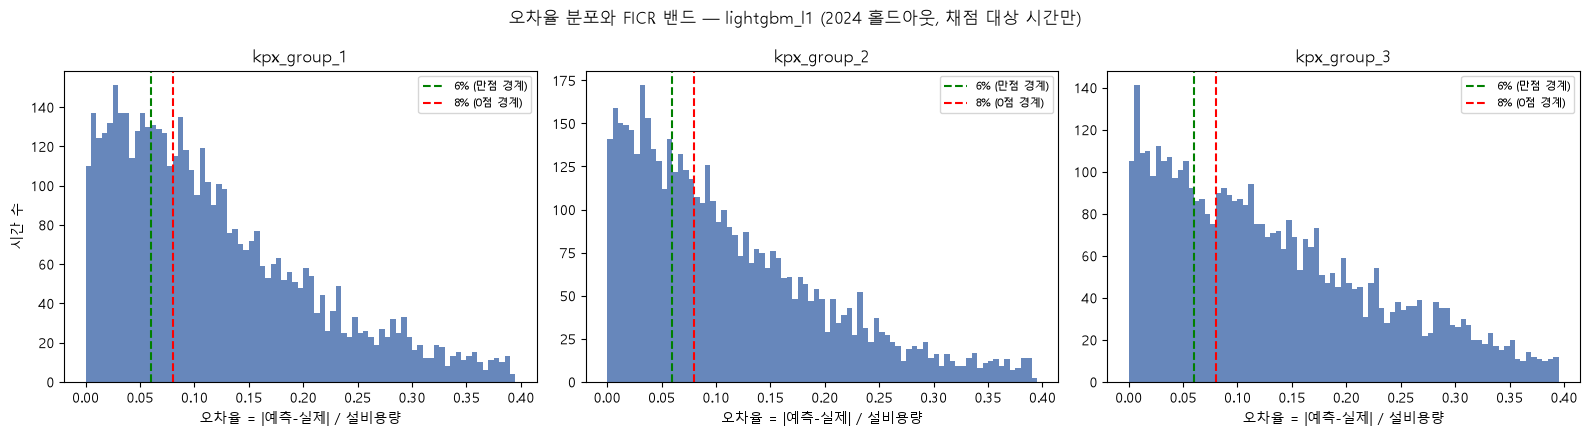

[FICR 밴드별 시간 비율]
         그룹 ≤6% (4점) 6~8% (3점) >8% (0점) 8~10% (아까운 구간)
kpx_group_1    31.3%     10.0%    58.7%           9.5%
kpx_group_2    34.5%      9.9%    55.5%           8.9%
kpx_group_3    28.1%      7.2%    64.7%           7.8%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
best_preds = all_preds[best_name] if best_name in all_preds else \
             {g: feat_train.loc[hold, f"pc_pred_{g}"].to_numpy() for g in TARGET_COLS}

band_rows = []
for ax, g in zip(axes, TARGET_COLS):
    er = error_rate(best_preds, g)
    ax.hist(er, bins=np.arange(0, 0.4, 0.005), color="#4C72B0", alpha=0.85)
    ax.axvline(0.06, color="green", ls="--", lw=1.5, label="6% (만점 경계)")
    ax.axvline(0.08, color="red", ls="--", lw=1.5, label="8% (0점 경계)")
    ax.set_xlabel("오차율 = |예측-실제| / 설비용량"); ax.set_title(g)
    ax.legend(fontsize=8)

    band_rows.append({
        "그룹": g,
        "≤6% (4점)": f"{(er <= 0.06).mean()*100:.1f}%",
        "6~8% (3점)": f"{((er > 0.06) & (er <= 0.08)).mean()*100:.1f}%",
        ">8% (0점)": f"{(er > 0.08).mean()*100:.1f}%",
        "8~10% (아까운 구간)": f"{((er > 0.08) & (er <= 0.10)).mean()*100:.1f}%",
    })
axes[0].set_ylabel("시간 수")
fig.suptitle(f"오차율 분포와 FICR 밴드 — {best_name} (2024 홀드아웃, 채점 대상 시간만)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase3_ficr_band.png", dpi=120)
plt.show()

print("[FICR 밴드별 시간 비율]")
print(pd.DataFrame(band_rows).to_string(index=False))

## 11. 피처 중요도 — 모델은 무엇을 보고 있는가

Phase 2에서 만든 물리 피처(`pc_pred_*`)가 실제로 상위에 오는지 확인한다.
상위에 없다면 물리 하이브리드 설계가 헛돈 것이므로 다시 봐야 한다.

LightGBM의 **gain 중요도**(그 피처로 자를 때 손실이 얼마나 줄었는지의 합)를 쓴다.
단순 사용 횟수(split)보다 실제 기여를 잘 반영한다.

[lightgbm_l1 — gain 중요도 상위 20 (비율)]
                                kpx_group_1  kpx_group_2  kpx_group_3     평균
pc_pred_kpx_group_1_roll5_mean       0.2136       0.0970       0.1605 0.1570
gfs_g5_ws850                         0.0411       0.0306       0.0350 0.0356
ldaps_g13_ws117_roll5_mean           0.0285       0.0336       0.0349 0.0323
gfs_ws850_mean                       0.0346       0.0231       0.0250 0.0276
pc_pred_kpx_group_1_roll3_mean       0.0274       0.0111       0.0221 0.0202
ldaps_g12_ws10                       0.0184       0.0129       0.0195 0.0169
doy_sin                              0.0167       0.0145       0.0143 0.0152
pc_pred_kpx_group_1_lead3            0.0176       0.0077       0.0149 0.0134
doy_cos                              0.0165       0.0131       0.0102 0.0133
pc_pred_kpx_group_1_lead2            0.0049       0.0118       0.0220 0.0129
gfs_g2_wd100_sin                     0.0175       0.0119       0.0090 0.0128
ldaps_g13_ws117_lead3                0.0

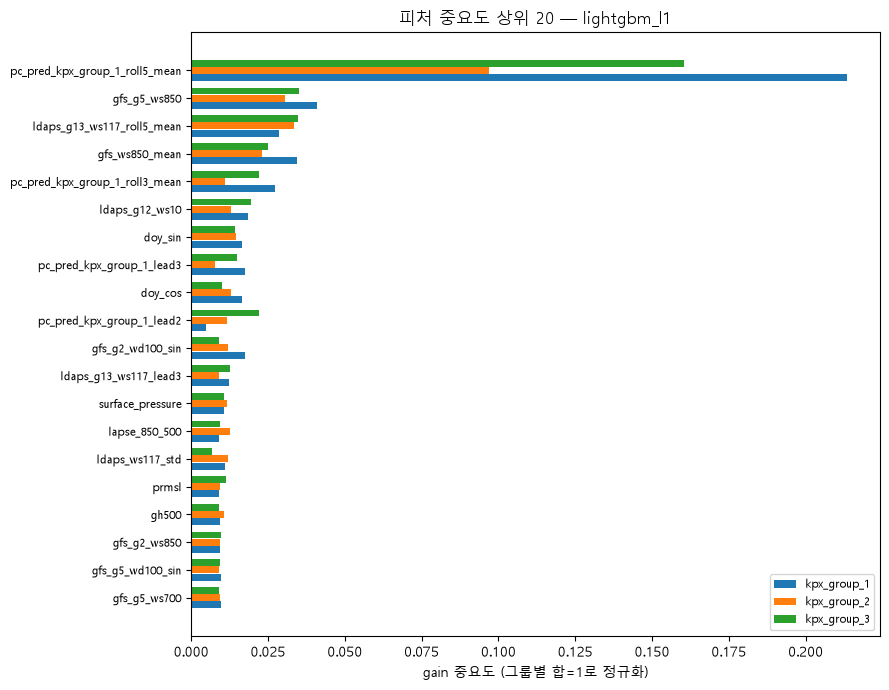


물리 예측치(pc_pred*) 계열이 차지하는 중요도 비중: 23.6%


In [14]:
imp_model = "lightgbm_l1"
imp_rows = []
for g in TARGET_COLS:
    b = fitted_models[imp_model][g]
    imp = pd.Series(b.feature_importance(importance_type="gain"), index=b.feature_name())
    imp_rows.append((imp / imp.sum()).rename(g))
imp_tbl = pd.concat(imp_rows, axis=1)
imp_tbl["평균"] = imp_tbl.mean(axis=1)
top = imp_tbl.sort_values("평균", ascending=False).head(20)

print(f"[{imp_model} — gain 중요도 상위 20 (비율)]")
print(top.to_string(float_format=lambda x: f"{x:.4f}"))

t = top.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(t))
for i, g in enumerate(TARGET_COLS):
    ax.barh(y + (i - 1) * 0.26, t[g], height=0.25, label=g)
ax.set_yticks(y); ax.set_yticklabels(t.index, fontsize=8)
ax.set_xlabel("gain 중요도 (그룹별 합=1로 정규화)")
ax.legend(fontsize=8); ax.set_title(f"피처 중요도 상위 20 — {imp_model}")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase3_feature_importance.png", dpi=120)
plt.show()

pc_share = imp_tbl.loc[[c for c in imp_tbl.index if c.startswith("pc_pred")], "평균"].sum()
print(f"\n물리 예측치(pc_pred*) 계열이 차지하는 중요도 비중: {pc_share*100:.1f}%")

## 12. 실험 로그 기록

CLAUDE.md 5번 규칙대로 `experiments/log.csv`에 모든 실험을 기록한다.
`git rev-parse --short HEAD`(읽기 전용)로 현재 커밋 해시를 조회해 함께 남긴다.
워킹트리에 커밋되지 않은 변경이 있으면 그 사실도 기록한다 (재현 시 혼선 방지).

In [15]:
def git_state():
    """현재 커밋 해시와 워킹트리 청결 여부를 조회한다 (읽기 전용 명령만 사용 -- CLAUDE.md 3번)."""
    try:
        h = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
        dirty = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip()
        return h, ("dirty" if dirty else "clean")
    except Exception:
        return "unknown", "unknown"


git_hash, tree_state = git_state()
today = pd.Timestamp.today().strftime("%Y-%m-%d")

log_rows = []
for i, (name, r) in enumerate(comp.iterrows(), start=1):
    log_rows.append({
        "exp_id": f"exp{i:03d}",
        "date": today,
        "git_hash": f"{git_hash}({tree_state})",
        "model": name,
        "features": f"phase2_{len(FEATURE_COLS)}feat",
        "total_score": round(r["total_score"], 6),
        "one_minus_nmae": round(r["one_minus_nmae"], 6),
        "ficr": round(r["ficr"], 6),
        "nmae_g1": round(r["nmae_1"], 6), "nmae_g2": round(r["nmae_2"], 6), "nmae_g3": round(r["nmae_3"], 6),
        "ficr_g1": round(r["ficr_1"], 6), "ficr_g2": round(r["ficr_2"], 6), "ficr_g3": round(r["ficr_3"], 6),
        "val_period": "2024-01-01~2024-12-31",
        "fit_seconds": round(r["fit_seconds"], 1),
        "public_score": "",       # 리더보드 제출 후 채운다 (CLAUDE.md 5번)
        "note": "phase3 model selection",
    })

log_df = pd.DataFrame(log_rows)
log_path = EXP_DIR / "log.csv"
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")   # 제출물 인코딩 규칙과 동일
print(f"저장: {log_path} ({len(log_df)}행)")
print(log_df[["exp_id", "model", "total_score", "one_minus_nmae", "ficr", "fit_seconds"]].to_string(index=False))

저장: experiments\log.csv (8행)
exp_id                model  total_score  one_minus_nmae     ficr  fit_seconds
exp001          lightgbm_l1     0.607436        0.868979 0.345893         21.9
exp002           xgboost_l1     0.604894        0.868897 0.340890         15.0
exp003         catboost_mae     0.601640        0.868027 0.335253         85.0
exp004    lightgbm_residual     0.599552        0.866630 0.332474         32.7
exp005          lightgbm_l2     0.596887        0.867890 0.325885          6.7
exp006                ridge     0.592596        0.868754 0.316438          0.3
exp007     baseline_pc_pred     0.571717        0.843660 0.299773          0.0
exp008 baseline_pc_pred_rho     0.560099        0.838922 0.281275          0.0


## 13. 재현성 확인 — 같은 코드를 두 번 돌리면 같은 결과가 나오는가

2차 평가 요건이다 (CLAUDE.md 12번: "Private Score가 오차 범위 내에서 복원 가능해야 한다").
최고 모델을 **처음부터 다시 학습**해 예측값이 비트 단위로 같은지 확인한다.
다르다면 멀티스레드 비결정성이 남아 있다는 뜻이므로 지금 잡아야 한다.

In [16]:
if best_name in dict(MODEL_SPECS):
    fn = dict(MODEL_SPECS)[best_name]
    same = True
    for g in TARGET_COLS:
        p2, _, _ = fn(g, build_splits(g))
        identical = np.array_equal(all_preds[best_name][g], p2)
        max_diff = float(np.abs(all_preds[best_name][g] - p2).max())
        print(f"  {g}: 완전 동일 = {identical} | 최대 차이 = {max_diff:.3e}")
        same &= identical
    print(f"\n재현성: {'✔ 두 번 실행 결과가 완전히 같다' if same else '✘ 결과가 다르다 -- 비결정 요소를 제거해야 한다'}")
else:
    print(f"최고 모델이 베이스라인({best_name})이므로 재학습 재현성 확인은 생략한다.")

  kpx_group_1: 완전 동일 = True | 최대 차이 = 0.000e+00


  kpx_group_2: 완전 동일 = True | 최대 차이 = 0.000e+00


  kpx_group_3: 완전 동일 = True | 최대 차이 = 0.000e+00

재현성: ✔ 두 번 실행 결과가 완전히 같다
